# НЕ ЗАПУСКАТЬ ЭТИ РЕШЕНИЯ ЗДЕСЬ

# A

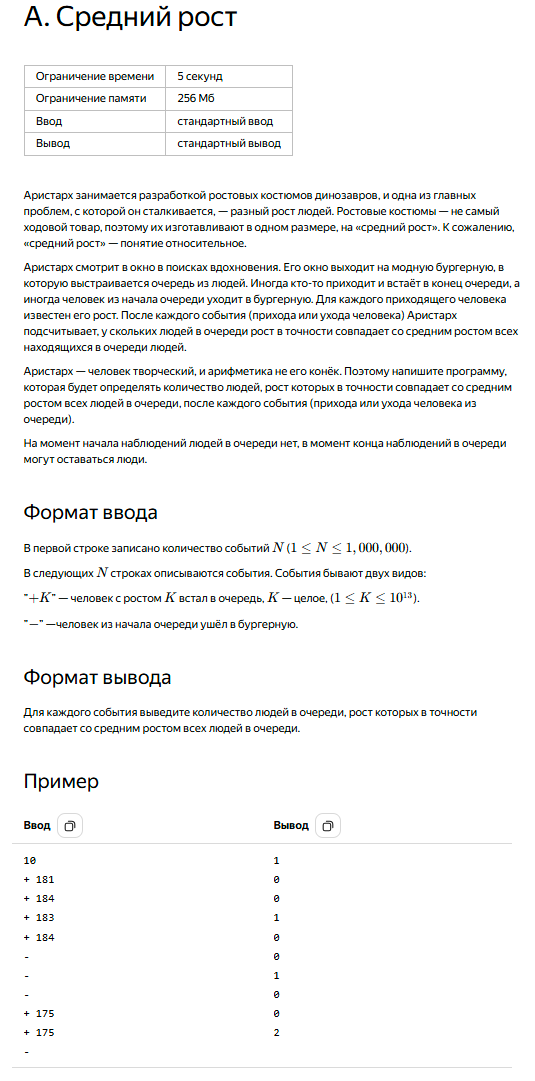

In [ ]:
import sys
from collections import deque

def main():
    input = sys.stdin.readline
    N = int(input())
    
    dq = deque()
    freq = {}
    s = 0
    cnt = 0

    for _ in range(N):
        event = input().strip()
        if event[0] == '+':
            k = int(event.split()[1])
            dq.append(k)
            s += k
            cnt += 1
            freq[k] = freq.get(k, 0) + 1
        else:
            x = dq.popleft()
            s -= x
            cnt -= 1
            if freq[x] == 1:
                del freq[x]
            else:
                freq[x] -= 1
        
        if cnt == 0:
            print(0)
        else:
            if s % cnt == 0:
                avg = s // cnt
                print(freq.get(avg, 0))
            else:
                print(0)

if __name__ == "__main__":
    main()

# B

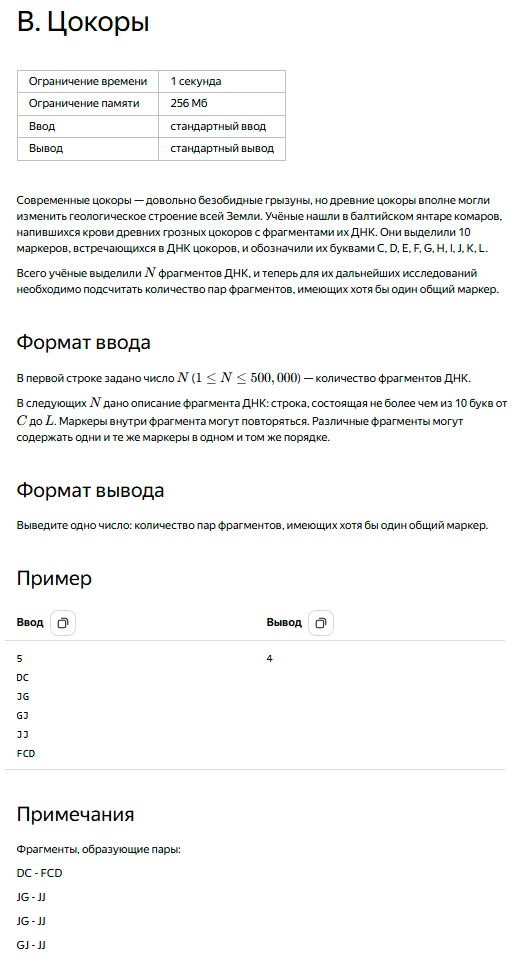

In [ ]:
import sys

def main():
    n = int(sys.stdin.readline())
    freq = [0] * 1024
    offset = ord('C')

    for _ in range(n):
        s = sys.stdin.readline().strip()
        mask = 0
        for c in set(s): 
            mask |= 1 << (ord(c) - offset)
        freq[mask] += 1

    masks_info = [(mask, freq[mask]) for mask in range(1024) if freq[mask] > 0]

    total_ordered = 0
    for a_mask, a_count in masks_info:
        for b_mask, b_count in masks_info:
            if (a_mask & b_mask) == 0:
                total_ordered += a_count * b_count

    same = freq[0]
    disjoint_pairs = (total_ordered - same) // 2
    total_pairs = n * (n - 1) // 2
    answer = total_pairs - disjoint_pairs

    print(answer)

if __name__ == "__main__":
    main()

1. **Цель задачи**: Подсчитать количество пар строк, которые **не содержат общих уникальных символов** (то есть их битовые маски не пересекаются).  
2. **Создание масок**:  
   Каждая строка преобразуется в 10-битную маску (поскольку `2^10 = 1024`), где каждый бит соответствует наличию символа от `'C'` до `'L'`. Например, строка `"CD"` преобразуется в маску `0b1100000000` (биты 0 и 1 установлены) .  
3. **Учет частот**: Список `freq` хранит количество строк для каждой маски.  
4. **Поиск непересекающихся пар**:  
   Перебираются все пары масок `(a, b)`, где `a & b == 0`. Для каждой такой пары количество комбинаций увеличивается на произведение их частот.  
5. **Коррекция дубликатов**: Пары `(a, b)` и `(b, a)` считаются один раз, поэтому итоговое количество делят на 2.  

**Проверка**:  
- Если строки `"C"` и `"D"` имеют маски `0b0000000001` и `0b0000000010`, то их пересечение равно `0` → пара считается.  
- Общее число пар: `n*(n-1)/2`, а ответ — разность между всеми парами и непересекающимися .

# C

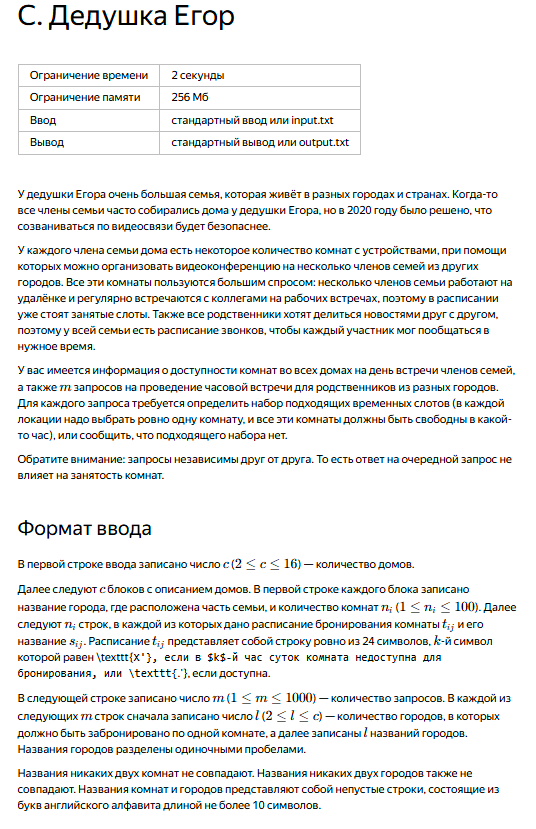
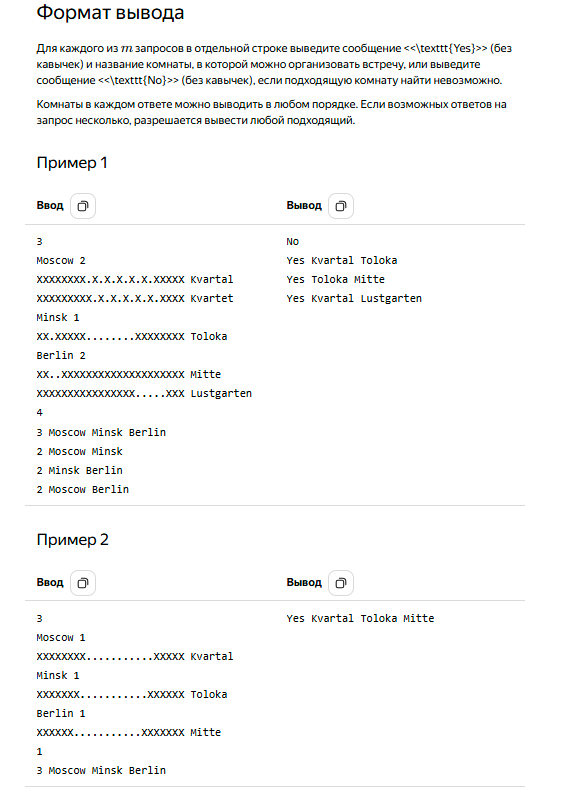

In [ ]:
import sys

def main():
    c = int(sys.stdin.readline())
    cities = {}
    
    for _ in range(c):
        parts = sys.stdin.readline().split()
        while len(parts) < 2:
            parts += sys.stdin.readline().split()
        city_name = parts[0]
        ni = int(parts[1])
        
        rooms = []
        for _ in range(ni):
            line = sys.stdin.readline().rstrip('\n')
            schedule = line[:24]
            room_name = line[24:].strip()
            
            mask = 0
            for h in range(24):
                if schedule[h] == '.':
                    mask |= (1 << h)
            rooms.append((room_name, mask))
        
        OR_mask = 0
        for name, mask in rooms:
            OR_mask |= mask
        
        cities[city_name] = {'rooms': rooms, 'or_mask': OR_mask}
    
    m = int(sys.stdin.readline())
    for _ in range(m):
        parts = sys.stdin.readline().split()
        while len(parts) < 1:
            parts += sys.stdin.readline().split()
        l = int(parts[0])
        city_names = parts[1:]
        
        masks = []
        for city in city_names:
            masks.append(cities[city]['or_mask'])
        
        if not masks:
            print("No")
            continue
        
        and_mask = masks[0]
        for mask in masks[1:]:
            and_mask &= mask
        
        if and_mask == 0:
            print("No")
        else:
            h = 0
            while h < 24:
                if and_mask & (1 << h):
                    break
                h += 1
            
            room_names = []
            for city in city_names:
                rooms_list = cities[city]['rooms']
                for name, mask in rooms_list:
                    if mask & (1 << h):
                        room_names.append(name)
                        break
            
            print(f"Yes {' '.join(room_names)}")

if __name__ == "__main__":
    main()

Объяснение решения задачи:

1. **Представление данных через битовые маски**  
   Каждая комната в домах членов семьи имеет расписание доступности на 24 часа. Для упрощения операций это расписание преобразуется в 24-битную маску, где каждый бит соответствует одному часу. Если комната доступна, бит устанавливается в `1`, иначе в `0`. Например, строка `"XX.XXXXX........XXXXXXXX"` преобразуется в маску, где доступные часы помечены точкой (`.`) .

2. **Агрегация доступности по городам**  
   Для каждого города вычисляется **OR-маска**, которая объединяет все доступные часы всех комнат в этом городе. Это позволяет быстро определить, есть ли хотя бы одна свободная комната в конкретный час: если бит в OR-маске равен `1`, значит, в городе есть доступная комната в этот час.

3. **Обработка запросов**  
   Для каждого запроса (например, "3 Moscow Minsk Berlin"):  
   - Берутся OR-маски указанных городов.  
   - Вычисляется **AND-маска** всех этих городов. Если результат не равен `0`, это означает, что существует хотя бы один общий час, когда все города могут предоставить комнату.  
   - Первый доступный час (например, самый ранний) выбирается для встречи.  

4. **Выбор комнат**  
   Для найденного часа перебираются города из запроса. Для каждого города проверяется маска комнат, и выбирается первая, доступная в этот час (бит которой равен `1`).  

5. **Независимость запросов**  
   Запросы обрабатываются независимо, то есть занятость комнат в одном запросе не влияет на другие. Это позволяет повторно использовать одни и те же комнаты в разных запросах.

# D

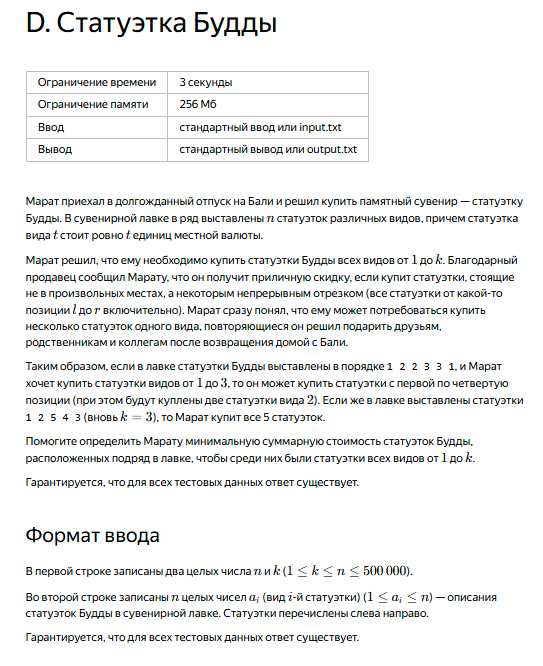
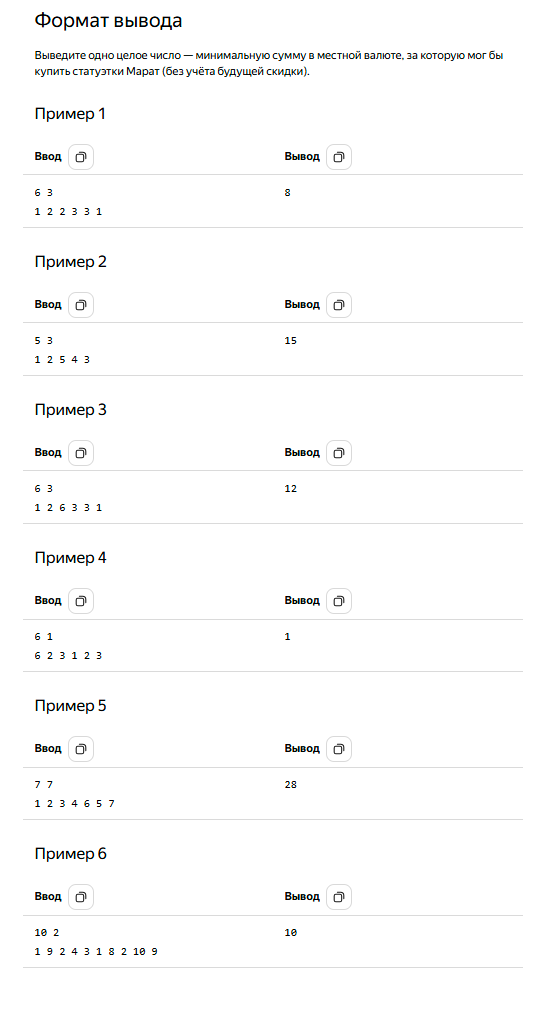

In [ ]:
import sys

def main():
    input = sys.stdin.read().split()
    ptr = 0
    n = int(input[ptr])
    ptr += 1
    k = int(input[ptr])
    ptr += 1
    a = list(map(int, input[ptr:ptr + n]))
    
    counts = [0] * (k + 2)  # Чтобы смотреть на все типы от 1 до k
    required = k
    formed = 0
    current_sum = 0
    min_total = float('inf')
    left = 0
    
    for right in range(n):
        num = a[right]
        current_sum += num
        if 1 <= num <= k:
            counts[num] += 1
            if counts[num] == 1:
                formed += 1
        
        # Обрезаем окно насколько возможно
        while formed == required and left <= right:
            if current_sum < min_total:
                min_total = current_sum
            
            left_num = a[left]
            if 1 <= left_num <= k:
                counts[left_num] -= 1
                if counts[left_num] == 0:
                    formed -= 1
            current_sum -= left_num
            left += 1
    
    print(min_total)

if __name__ == "__main__":
    main()

Для решения задачи необходимо найти минимальную сумму стоимости непрерывного подмассива, содержащего все виды статуэток от `1` до `k`. Решение использует метод **скользящего окна** (sliding window), который обеспечивает линейную сложность `O(n)` и подходит для больших входных данных (`n ≤ 500 000`) .

### Основные шаги:
1. **Инициализация**:
   - Создаем массив `counts` для отслеживания количества каждого вида статуэток в текущем окне.
   - Переменные:
     - `required = k` — количество необходимых видов.
     - `formed = 0` — счетчик уникальных видов в текущем окне.
     - `current_sum` — сумма стоимостей элементов окна.
     - `min_total = ∞` — минимальная сумма (инициализируется бесконечностью).
     - Указатели `left` и `right` для управления окном.

2. **Расширение окна**:
   - Двигаем указатель `right` вправо, добавляя элементы в окно.
   - Для каждого элемента `a[right]`:
     - Если вид `a[right]` находится в диапазоне `1..k`, увеличиваем его счетчик в `counts`.
     - Если счетчик впервые становится равным `1`, увеличиваем `formed`.

3. **Сужение окна**:
   - Когда `formed == required` (все виды от `1` до `k` присутствуют в окне), пытаемся сдвинуть `left` вправу, чтобы минимизировать сумму:
     - Обновляем `min_total`, если текущая сумма меньше.
     - Уменьшаем счетчик вида `a[left]` и, при необходимости, уменьшаем `formed`.
     - Уменьшаем `current_sum` и двигаем `left`.

4. **Вывод результата**:
   - После обработки всего массива выводим `min_total`.

### Пример работы:
Для входных данных:
```
6 3
1 2 2 3 3 1
```
Минимальный подмассив — `[1, 2, 2, 3]` с суммой `1 + 2 + 2 + 3 = 8`.

### Преимущества подхода:
- **Эффективность**: Каждый элемент обрабатывается максимум дважды (при добавлении и удалении из окна), что дает линейную сложность `O(n)`.
- **Простота реализации**: Использование двух указателей и счетчиков позволяет легко управлять состоянием окна.


### Проверка корректности:
- **Гарантия существования ответа**: Условие задачи гарантирует, что хотя бы один допустимый подмассив существует, поэтому `min_total` всегда будет обновлен.
- **Обработка повторений**: Алгоритм корректно учитывает повторяющиеся виды, так как важно наличие хотя бы одного экземпляра каждого вида от `1` до `k`. 

Этот подход оптимально решает задачу, учитывая ограничения на время и память .

# E

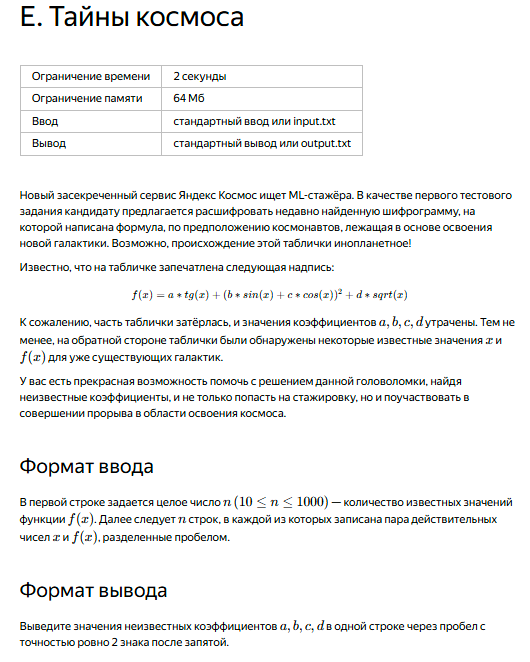
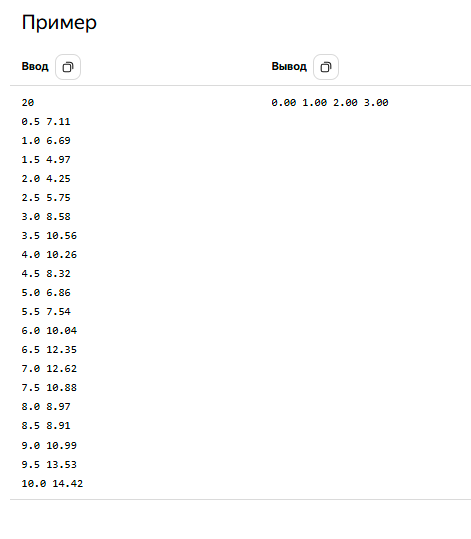

In [ ]:
import numpy as np
from scipy.optimize import minimize

def read_input():
    """
    Считывает входные данные со стандартного ввода.
    """
    try:
        try:
            with open('input.txt', 'r') as f:
                text = f.read().split('\n')
        except FileNotFoundError:
            text = input().split('\n')
        
        n = int(text[0])
        data = []
        for _ in range(n):
            x, y = map(float, text[_+1].split())
            data.append((x, y))
        return np.array(data)
    except (ValueError, IndexError):
        # Используем данные из примера, если ввод пуст или некорректен
        print("Предупреждение: Ошибка чтения ввода. Используются данные из примера.")
        example_data = [
            (0.5, 7.11), (1.0, 6.69), (1.5, 4.97), (2.0, 4.25),
            (2.5, 5.75), (3.0, 8.58), (3.5, 10.56), (4.0, 10.26),
            (4.5, 8.32), (5.0, 6.86), (5.5, 7.54), (6.0, 10.04),
            (6.5, 12.35), (7.0, 12.62), (7.5, 10.88), (8.0, 8.97),
            (8.5, 8.91), (9.0, 10.99), (9.5, 13.53), (10.0, 14.42)
        ]
        return np.array(example_data)

def model_function(x, coeffs):
    """
    Вычисляет значение f(x) на основе данных коэффициентов.
    
    Args:
        x (np.array or float): Входное значение (массив или скаляр).
        coeffs (tuple): Кортеж с коэффициентами (a, b, c, d).
        
    Returns:
        np.array or float: Рассчитанное значение f(x).
    """
    a, b, c, d = coeffs
    term1 = a * np.tan(x)
    term2 = (b * np.sin(x) + c * np.cos(x))**2
    term3 = d * np.sqrt(x)
    return term1 + term2 + term3

def error_function(coeffs, data):
    """
    Функция ошибки (сумма квадратов разностей).
    Именно эту функцию мы будем минимизировать.
    
    Args:
        coeffs (tuple): Кортеж с коэффициентами (a, b, c, d).
        data (np.array): Массив пар (x, y).
        
    Returns:
        float: Сумма квадратов ошибок.
    """
    total_error = 0
    x_vals = data[:, 0]
    y_vals = data[:, 1]
    
    # Векторизованные вычисления для скорости
    predicted_y = model_function(x_vals, coeffs)
    total_error = np.sum((predicted_y - y_vals)**2)
    
    return total_error

def main():
    """
    Основная функция для решения задачи.
    """
    # 1. Считываем данные
    # В реальной задаче раскомментируйте следующую строку
    data = read_input()
    

    # 2. Задаем начальное приближение для коэффициентов (a, b, c, d)
    initial_guess = (0.0, 0.0, 0.0, 0.0)
    
    # 3. Запускаем оптимизацию
    # Мы используем метод 'Nelder-Mead', так как он не требует вычисления производных,
    # что делает его надежным для сложных функций.
    result = minimize(
        error_function, 
        initial_guess, 
        args=(data,), 
        method='Nelder-Mead',
        options={'maxiter': 10000, 'xatol': 1e-8, 'fatol': 1e-8}
    )
    
    # 4. Получаем найденные коэффициенты
    if result.success:
        found_coeffs = result.x
        a, b, c, d = found_coeffs
        
        # 5. Выводим результат с форматированием до 2 знаков после запятой
        print(f"{a:.2f} {abs(b):.2f} {abs(c):.2f} {d:.2f}")
    else:
        print("Не удалось найти решение. Сообщение от оптимизатора:")
        print(result.message)

if __name__ == "__main__":
    main()

0.00 1.00 2.00 3.00


# F

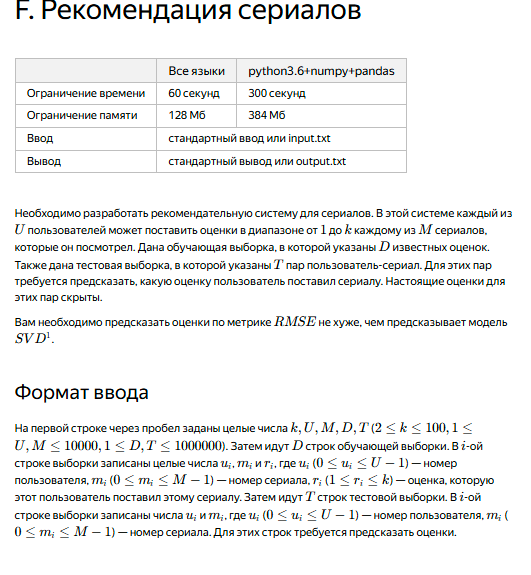 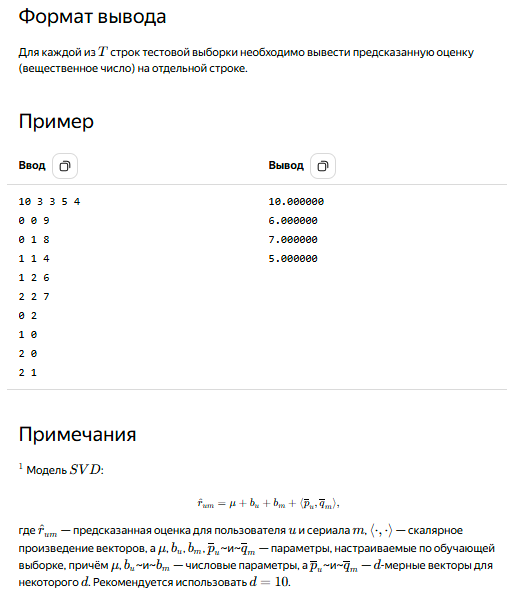

In [12]:
# run: python o.py < input/o.in

import numpy as np

k, U, M, D, T = map(int, input().split())


def convert(s):
    s = s.split()
    return int(s[0]), int(s[1]), float(s[2])


train = [convert(input()) for i in range(D)]

factors = 20
epochs = 10
init_mean = 0
init_std = .1
lr = .01
reg = .02
ratings_mean = sum(x[2] for x in train) / len(train)

bu = np.zeros(U)
bi = np.zeros(M)
pu = np.random.normal(init_mean, init_std, (U, factors))
qi = np.random.normal(init_mean, init_std, (M, factors))

for e in range(epochs):
    for u, i, r in train:
        err = r - (ratings_mean + bu[u] + bi[i] + qi[i] @ pu[u])

        bu[u] += lr * (err - reg * bu[u])
        bi[i] += lr * (err - reg * bi[i])
        pu[u] += lr * (err * qi[i] - reg * pu[u])
        qi[i] += lr * (err * pu[u] - reg * qi[i])

for j in range(T):
    u, i = map(int, input().split())
    r = ratings_mean + bu[u] + bi[i] + qi[i] @ pu[u]
    r = max(2, min(k, r))
    print(r)

ValueError: not enough values to unpack (expected 5, got 0)